In [ ]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utils_plot
import kind

# Training our KIND framework on synthetic data

### Stationary dataset

In the synthetic case, the stationary time series include pure 10Hz signals, 24Hz signals, as well as their sum. This is displayed below.


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



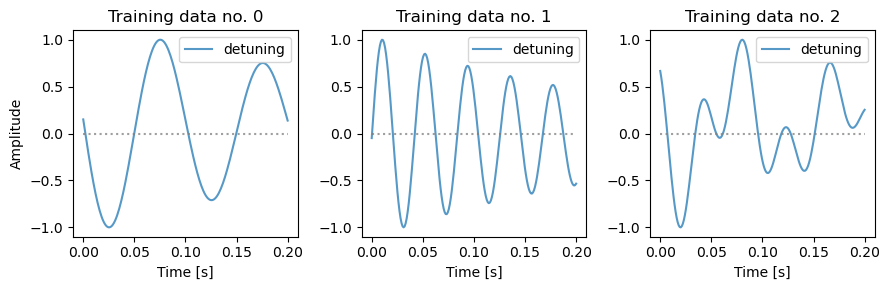

In [2]:
# --!------------------------------------------------------!
# --! display stationary dataset

datadir               = '../../data/care/train_sim_g'
timeseries_ndim       = 1
timeseries_nsample    = 200
timestep              = 0.001

# --! subtimeseries give us additional flexibility by allowing to work with subportions
# --! of original sampled timeseries
subtimeseries_nsample = timeseries_nsample

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep)

### Transient dataset

The transient dataset includes transitions from 10 Hz to 24 Hz and back to 10 Hz.


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



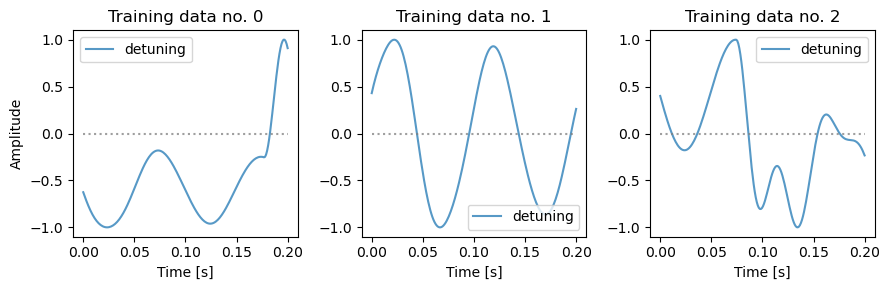

In [3]:
# --!------------------------------------------------------!
# --! display transient dataset

datadir               = '../../data/care/train_sim_l'
timeseries_ndim       = 1
timeseries_nsample    = 200
timestep              = 0.001

# --! subtimeseries give us additional flexibility by allowing to work with subportions
# --! of original sampled timeseries
subtimeseries_nsample = timeseries_nsample

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep)

### Mixed dataset

The mixed dataset is just a mix of stationary and transient time series. We do not show it here explicitly

### Model instantiation

The model is instantiated with 6 basis functions: a sine and a cosine, as well as 4 polynomials (orders 1 to 4). We set parameter $\tau=40$, as this value allows the DMD-like stationary operator to consistently identify two distinct complex eigenvalue pairs corresponding to the fast and slow oscillatory modes.

In [4]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
#seed = 5
#torch.manual_seed(seed)

model_cfg = kind.model_config(

    timeseries_ndim    = timeseries_ndim,
    timeseries_nsample = subtimeseries_nsample, # by using subtimeseries we may work with fewer samples than originally sampled
    timestep           = timestep,

    fun = {
        'poly_1' : 1,
        'poly_2' : 1,
        'poly_3' : 1,
        'poly_4' : 1,
        'sin'    : 2,
        'cos'    : 2
    },

    param_kernsize     = 40
)

model = kind.model(model_cfg)

### Model training

The model is trained in one loop, i.e. first the stationary operator mean, then its variance, then the dynamic operator mean and so on.

In [5]:
# --!--------------------------------------------------------------------------
# --! train all phases in one loop

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : '../../data/care/train_sim_g',
    'transdatadir'          : '../../data/care/train_sim_l',
    'mixdatadir'            : '../../data/care/train_sim_mix',
    'timeseries_nsample'    : timeseries_nsample,
    'subtimeseries_nsample' : subtimeseries_nsample,
    'train_nfile'           : 7,
    'batsize'               : batsize,
    'nepoch'                : 100,
    'isverbose'             : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-4,
}

loss = []

while True:
    loss.append(model.fit(trainparam))
    if not model.fit_next():
        break

inf >> fit: entering stationary mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering stationary variance phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering dynamic mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file num

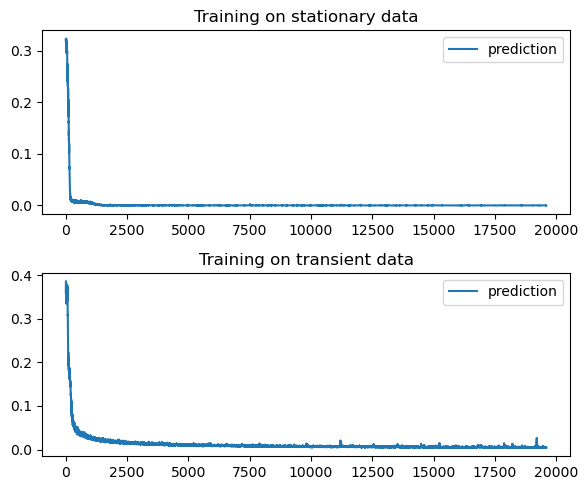

In [6]:
# --!--------------------------------------------------------------------------
# --! plot training statistics

with torch.no_grad():
    sta_stats = loss[0]
    dyn_stats = loss[2]

    plt.figure(figsize=(6, 5))

    plt.subplot(2, 1, 1)
    plt.title('Training on stationary data')
    plt.plot(sta_stats[0], label='prediction')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.title('Training on transient data')
    plt.plot(dyn_stats[0], label='prediction')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [7]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = True
print(model.operator_sta.model.weight)

if savemod_on:
    torch.save(model, '../../models/care/kind_sim.pt')

Parameter containing:
tensor([[-3.5482e-01, -5.7755e-01, -6.4352e-01, -6.2233e-01, -1.3854e-10,
          4.7757e-01],
        [ 1.5536e-01,  2.0472e-01, -2.3752e-03, -4.0815e-01,  3.0483e-10,
          3.7230e-02],
        [-4.4341e-01, -4.5358e-01,  5.4740e-01, -3.9199e-01, -8.6515e-11,
          4.1508e-01],
        [ 2.6654e-01, -1.4153e+00, -5.4269e-02,  2.3809e-01, -1.8002e-09,
          9.6351e-02],
        [-1.9049e-11,  1.1673e-09,  1.1675e-10, -6.6015e-10, -1.3609e-17,
          1.5642e-11],
        [ 4.7301e-01,  1.0267e+00,  9.3413e-02,  3.6495e-01,  4.8749e-10,
          5.9062e-01]])
